This file will be used to find the filenames for each current correlation data point to send to Josh so he can run his error bar algorithm on it

In [3]:
import sys
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\paper_data_and_simulations\helpers")


from data_file_helpers import *

# 1. Export Error Bar Files
This part packages the date and time codes for the filenames to send to Josh so he can run his bootstrapping algorithm

In [4]:
coupling_points = [
    'coupling_point_1',
    'coupling_point_2',
    'coupling_point_3',
    'coupling_point_4',
    'coupling_point_5',
    'coupling_point_6',
    'coupling_point_5_retake',
    'coupling_point_6_retake'
]

all_eigenstates = ['highest', 'highest_postselection']

In [5]:
config_filename = '../current_correlations_config.json'
data_filename = '../current_correlations_data.h5'

config = read_config(config_filename)
data = load_nested_dict_from_hdf5(data_filename)

# print_tree(config, max_level=5)
print_tree(data, max_level=3)


data
- coupling_point_1
- - disordered
- - highest
- - highest_postselection
- coupling_point_2
- - highest
- - highest_postselection
- coupling_point_3
- - disordered
- - highest
- - highest_postselection
- coupling_point_4
- - highest
- - highest_postselection
- - lowest
- coupling_point_5
- - disordered
- - highest
- - highest_postselection
- coupling_point_5_retake
- - disordered
- - highest
- - highest_postselection
- coupling_point_6
- - highest
- - highest_postselection
- coupling_point_6_retake
- - disordered
- - highest
- - highest_postselection
simulation
- highest
- - 0.01
- - 0.1
- - 0.2
- - 0.3
- - 0.5
- - 0.8
- - 1.0
- - 10.0
- - 2.0
- - 5.0
- - 50.0
- - no_dephasing
- - no_dephasing_ramp
- - real
- lowest
- - no_dephasing


In [10]:
pairs = [(i,i+1) for i in range(1,8)]
correlation_pairs = []
for i in range(len(pairs)):
    for j in range(i, len(pairs)):
        if i < j - 1:
            correlation_pairs.append((pairs[i], pairs[j]))

In [41]:

error_bar_data = {}

for i in range(len(coupling_points)):
    coupling_point = coupling_points[i]

    coupling_point_config = config[coupling_point]['data_config']
    coupling_point_data = data['data'][coupling_point]

    print(f'coupling_point: {coupling_point}')

    error_bar_data[coupling_point] = {}

    for j in range(len(all_eigenstates)):
        eigenstate = all_eigenstates[j]
        eigenstate_base = eigenstate.split('_')[0]

        if not eigenstate in coupling_point_data:
            continue

        error_bar_data[coupling_point][eigenstate] = {}

        for k in range(len(correlation_pairs)):
            correlation_pair_config = coupling_point_config[str(correlation_pairs[k])][eigenstate_base]

            error_bar_data[coupling_point][eigenstate][str(correlation_pairs[k])] = {}

            if 'year' in correlation_pair_config:
                year = correlation_pair_config['year']
                month = correlation_pair_config['month']
                day = correlation_pair_config['day']
                hour = correlation_pair_config['hour']
                minute = correlation_pair_config['minute']
                second = correlation_pair_config['second']

                filename_base = correlation_pair_config['filename_base']


                datecode = str(month) + str(day)
                timecode = str(hour) + str(minute) + str(second)

                error_bar_data[coupling_point][eigenstate][str(correlation_pairs[k])]['file_code'] = (year, datecode, timecode, filename_base)





            elif 'filename' in correlation_pair_config:
                filename = correlation_pair_config['filename']
                error_bar_data[coupling_point][eigenstate][str(correlation_pairs[k])]['filename'] = filename
            else:
                raise ValueError("No year or filename found in config for correlation pair {}".format(correlation_pairs[k]))

            # index

    
            correlation_pair_data = coupling_point_data[eigenstate][str(correlation_pairs[k])]
            times = correlation_pair_data['times']
            beamsplitter_time = correlation_pair_data['beamsplitter_time']
            time_index = np.argmin(np.abs(times - beamsplitter_time))

            error_bar_data[coupling_point][eigenstate][str(correlation_pairs[k])]['index'] = time_index


            correlation_value = correlation_pair_data['current_correlation'][time_index]
            error_bar_data[coupling_point][eigenstate][str(correlation_pairs[k])]['current_correlation'] = correlation_value

        
    print()

coupling_point: coupling_point_1

coupling_point: coupling_point_2

coupling_point: coupling_point_3

coupling_point: coupling_point_4

coupling_point: coupling_point_5

coupling_point: coupling_point_6

coupling_point: coupling_point_5_retake

coupling_point: coupling_point_6_retake



In [42]:
print_tree(error_bar_data, max_level=5)

coupling_point_1
- highest
- - ((1, 2), (3, 4))
- - - file_code
- - - index
- - - current_correlation
- - ((1, 2), (4, 5))
- - - file_code
- - - index
- - - current_correlation
- - ((1, 2), (5, 6))
- - - file_code
- - - index
- - - current_correlation
- - ((1, 2), (6, 7))
- - - file_code
- - - index
- - - current_correlation
- - ((1, 2), (7, 8))
- - - file_code
- - - index
- - - current_correlation
- - ((2, 3), (4, 5))
- - - file_code
- - - index
- - - current_correlation
- - ((2, 3), (5, 6))
- - - file_code
- - - index
- - - current_correlation
- - ((2, 3), (6, 7))
- - - file_code
- - - index
- - - current_correlation
- - ((2, 3), (7, 8))
- - - file_code
- - - index
- - - current_correlation
- - ((3, 4), (5, 6))
- - - file_code
- - - index
- - - current_correlation
- - ((3, 4), (6, 7))
- - - file_code
- - - index
- - - current_correlation
- - ((3, 4), (7, 8))
- - - file_code
- - - index
- - - current_correlation
- - ((4, 5), (6, 7))
- - - file_code
- - - index
- - - current_correlatio

In [43]:
error_bar_data_filename = 'error_bar_config.h5'
save_nested_dict_to_hdf5(error_bar_data_filename, error_bar_data, save_backup=False)

In [44]:
loaded_error_bar_data = load_nested_dict_from_hdf5(error_bar_data_filename)
print_tree(loaded_error_bar_data)

coupling_point_1
- highest
- - ((1, 2), (3, 4))
- - - current_correlation
- - - file_code
- - - index
- - ((1, 2), (4, 5))
- - - current_correlation
- - - file_code
- - - index
- - ((1, 2), (5, 6))
- - - current_correlation
- - - file_code
- - - index
- - ((1, 2), (6, 7))
- - - current_correlation
- - - file_code
- - - index
- - ((1, 2), (7, 8))
- - - current_correlation
- - - file_code
- - - index
- - ((2, 3), (4, 5))
- - - current_correlation
- - - file_code
- - - index
- - ((2, 3), (5, 6))
- - - current_correlation
- - - file_code
- - - index
- - ((2, 3), (6, 7))
- - - current_correlation
- - - file_code
- - - index
- - ((2, 3), (7, 8))
- - - current_correlation
- - - file_code
- - - index
- - ((3, 4), (5, 6))
- - - current_correlation
- - - file_code
- - - index
- - ((3, 4), (6, 7))
- - - current_correlation
- - - file_code
- - - index
- - ((3, 4), (7, 8))
- - - current_correlation
- - - file_code
- - - index
- - ((4, 5), (6, 7))
- - - current_correlation
- - - file_code
- - - inde

# 2. Export Error Bar Data
This part takes the resampled data from Josh's algorithm and adds the error bars to the `current_correlations_data.h5` data file.

In [11]:
correlation_config_filename = '..\\current_correlations_config.json'
loaded_correlation_config = read_config(correlation_config_filename)
# print_tree(loaded_correlation_config['coupling_point_1'])

In [12]:
correlation_data_filename = '..\\current_correlations_data.h5'
backup_dir = 'data_backups'
loaded_correlation_data = load_nested_dict_from_hdf5(correlation_data_filename)
print_tree(loaded_correlation_data['data']['coupling_point_1']['highest'], max_level=1)

((1, 2), (3, 4))
((1, 2), (4, 5))
((1, 2), (5, 6))
((1, 2), (6, 7))
((1, 2), (7, 8))
((2, 3), (4, 5))
((2, 3), (5, 6))
((2, 3), (6, 7))
((2, 3), (7, 8))
((3, 4), (5, 6))
((3, 4), (6, 7))
((3, 4), (7, 8))
((4, 5), (6, 7))
((4, 5), (7, 8))
((5, 6), (7, 8))
current_correlation_average_errors
current_correlation_average_readout_std_error
current_correlation_averages
distance_to_current_correlation_error
distance_to_current_correlation_value
distance_to_readout_std_error_value
distances
current_correlation_total
current_correlation_total_error
current_correlation_total_readout_std_error


In [15]:
bootstrap_filename = 'bootstrapped_error_bar_config.h5'
loaded_bootstrap_data = load_nested_dict_from_hdf5(bootstrap_filename)
print_tree(loaded_bootstrap_data)
# print_tree(loaded_bootstrap_data['coupling_point_5_retake'])

coupling_point_1
- highest
- - ((1, 2), (3, 4))
- - - file_code
- - - resampled_ncorr_means
- - - resampled_ncorr_stds
- - - current_correlation
- - - index
- - ((1, 2), (4, 5))
- - - file_code
- - - resampled_ncorr_means
- - - resampled_ncorr_stds
- - - current_correlation
- - - index
- - ((1, 2), (5, 6))
- - - file_code
- - - resampled_ncorr_means
- - - resampled_ncorr_stds
- - - current_correlation
- - - index
- - ((1, 2), (6, 7))
- - - file_code
- - - resampled_ncorr_means
- - - resampled_ncorr_stds
- - - current_correlation
- - - index
- - ((1, 2), (7, 8))
- - - file_code
- - - resampled_ncorr_means
- - - resampled_ncorr_stds
- - - current_correlation
- - - index
- - ((2, 3), (4, 5))
- - - file_code
- - - resampled_ncorr_means
- - - resampled_ncorr_stds
- - - current_correlation
- - - index
- - ((2, 3), (5, 6))
- - - file_code
- - - resampled_ncorr_means
- - - resampled_ncorr_stds
- - - current_correlation
- - - index
- - ((2, 3), (6, 7))
- - - file_code
- - - resampled_ncorr_mean

In [16]:
for i in range(len(coupling_points)):
    coupling_point = coupling_points[i]

    print(f'processing coupling point {coupling_point}')

    for j in range(len(all_eigenstates)):

        eigenstate = all_eigenstates[j]

        print(eigenstate)

        if not 'distances' in loaded_correlation_data['data'][coupling_point][eigenstate]:
            print(f'distances not found for coupling point {coupling_point} eigenstate {eigenstate} in correlation data')
            continue

        distances = loaded_correlation_data['data'][coupling_point][eigenstate]['distances']
        distance_to_current_correlation_value = loaded_correlation_data['data'][coupling_point][eigenstate]['distance_to_current_correlation_value']
        distance_to_readout_std_error_value = {str(d): [] for d in distance_to_current_correlation_value}
        
        data_dictionary = loaded_correlation_data['data'][coupling_point][eigenstate]

        
        for k in range(len(correlation_pairs)):
            correlation_pair = correlation_pairs[k]

            if str(correlation_pair) not in loaded_bootstrap_data[coupling_point][eigenstate]:
                print(f'correlation pair {correlation_pair} not found for coupling point {coupling_point} in bootstrap data')

            if not 'resampled_ncorr_means' in loaded_bootstrap_data[coupling_point][eigenstate][str(correlation_pair)]:
                print(f'failed for coupling point {coupling_point} correlation pair {correlation_pair}')
                continue

            readout_error_means = loaded_bootstrap_data[coupling_point][eigenstate][str(correlation_pair)]['resampled_ncorr_means']
            readout_error_stds = loaded_bootstrap_data[coupling_point][eigenstate][str(correlation_pair)]['resampled_ncorr_stds']

            coupling_1 = loaded_correlation_config[coupling_point]['coupling'][f'J_{correlation_pair[0][0]}{correlation_pair[0][1]}']
            coupling_2 = loaded_correlation_config[coupling_point]['coupling'][f'J_{correlation_pair[1][0]}{correlation_pair[1][1]}']

            
            times = loaded_correlation_data['data'][coupling_point][eigenstate][str(correlation_pair)]['times']

            beamsplitter_time = loaded_correlation_data['data'][coupling_point][eigenstate][str(correlation_pair)]['beamsplitter_time']
            time_index = np.argmin(np.abs(times - beamsplitter_time))


            # add in coupling units here
            data_dictionary[str(correlation_pair)]['readout_error_means'] = readout_error_means * np.abs(coupling_1) * np.abs(coupling_2)
            data_dictionary[str(correlation_pair)]['readout_error_stds'] = readout_error_stds * np.abs(coupling_1) * np.abs(coupling_2)

            # print(times)

            current_correlation_value_readout_std_error = data_dictionary[str(correlation_pair)]['readout_error_stds'][time_index]
            data_dictionary[str(correlation_pair)]['current_correlation_value_readout_std_error'] = current_correlation_value_readout_std_error

            distance = np.abs(np.min(correlation_pair[0])-np.min(correlation_pair[1]))
            distance_to_readout_std_error_value[str(distance)].append(current_correlation_value_readout_std_error)


        # set total chiral current error
        current_correlation_average_readout_std_error = []
        for d in distances:
            average_readout_std_error = np.sqrt(np.sum(np.power(distance_to_readout_std_error_value[str(d)], 2)))/len(distance_to_readout_std_error_value[str(d)])
            current_correlation_average_readout_std_error.append(average_readout_std_error)

        current_correlation_total_readout_std_error = np.sqrt(np.sum(np.power(current_correlation_average_readout_std_error, 2)))

        data_dictionary['current_correlation_average_readout_std_error'] = current_correlation_average_readout_std_error
        data_dictionary['current_correlation_total_readout_std_error'] = current_correlation_total_readout_std_error
        data_dictionary['distance_to_readout_std_error_value'] = distance_to_readout_std_error_value

        keys = ('data',coupling_point, eigenstate)
        update_data_file(correlation_data_filename, data_dictionary, keys, backup_dir=backup_dir, save_backup=True)



processing coupling point coupling_point_1
highest
highest_postselection
processing coupling point coupling_point_2
highest
highest_postselection
processing coupling point coupling_point_3
highest
highest_postselection
processing coupling point coupling_point_4
highest
highest_postselection
processing coupling point coupling_point_5
highest
highest_postselection
processing coupling point coupling_point_6
highest
highest_postselection
processing coupling point coupling_point_5_retake
highest
highest_postselection
processing coupling point coupling_point_6_retake
highest
highest_postselection
distances not found for coupling point coupling_point_6_retake eigenstate highest_postselection in correlation data


In [17]:
correlation_data_filename = '..\\current_correlations_data.h5'
backup_dir = 'data_backups'
reloaded_correlation_data = load_nested_dict_from_hdf5(correlation_data_filename)
print_tree(reloaded_correlation_data['data']['coupling_point_3']['highest'], max_level=1)

((1, 2), (3, 4))
((1, 2), (4, 5))
((1, 2), (5, 6))
((1, 2), (6, 7))
((1, 2), (7, 8))
((2, 3), (4, 5))
((2, 3), (5, 6))
((2, 3), (6, 7))
((2, 3), (7, 8))
((3, 4), (5, 6))
((3, 4), (6, 7))
((3, 4), (7, 8))
((4, 5), (6, 7))
((4, 5), (7, 8))
((5, 6), (7, 8))
current_correlation_average_errors
current_correlation_average_readout_std_error
current_correlation_averages
distance_to_current_correlation_error
distance_to_current_correlation_value
distance_to_readout_std_error_value
distances
current_correlation_total
current_correlation_total_error
current_correlation_total_readout_std_error


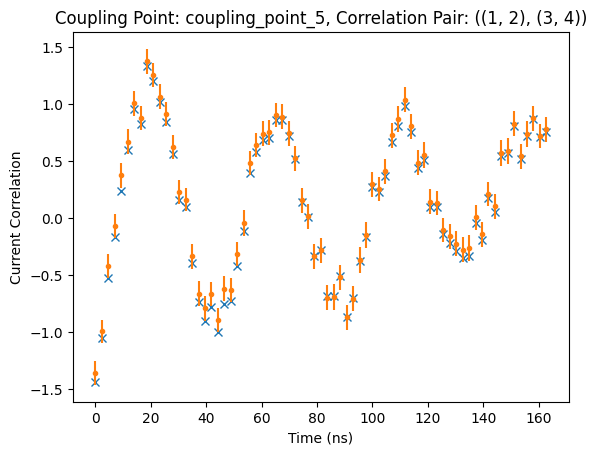

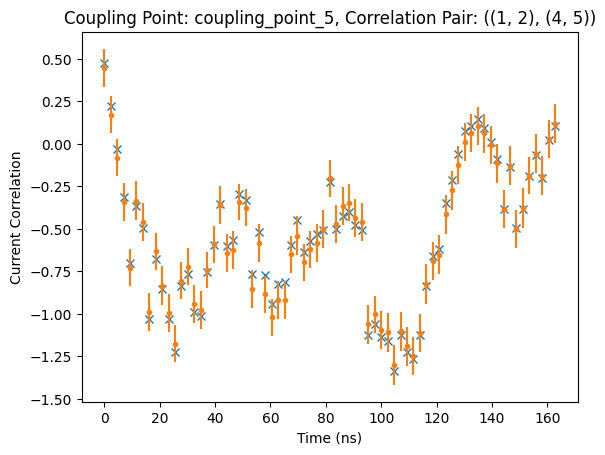

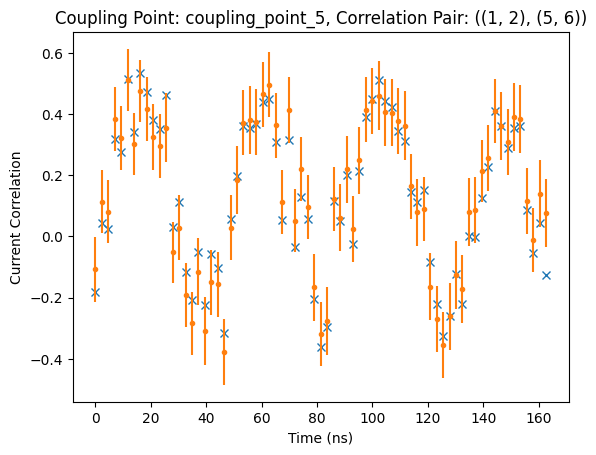

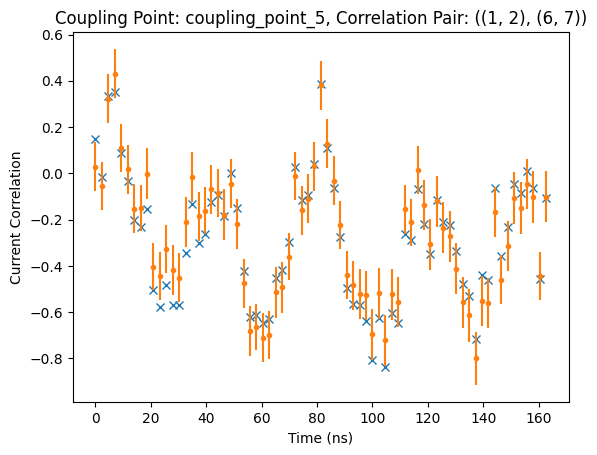

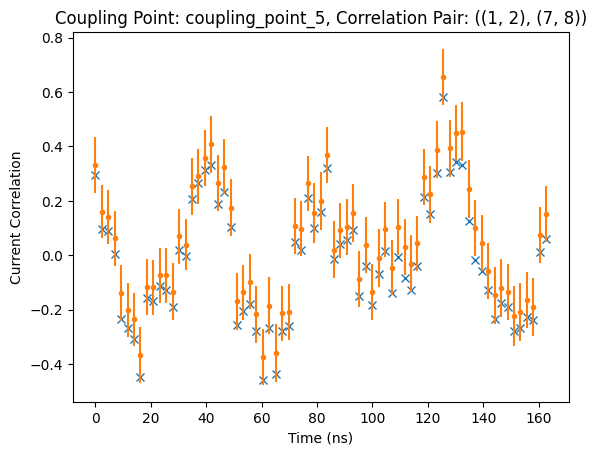

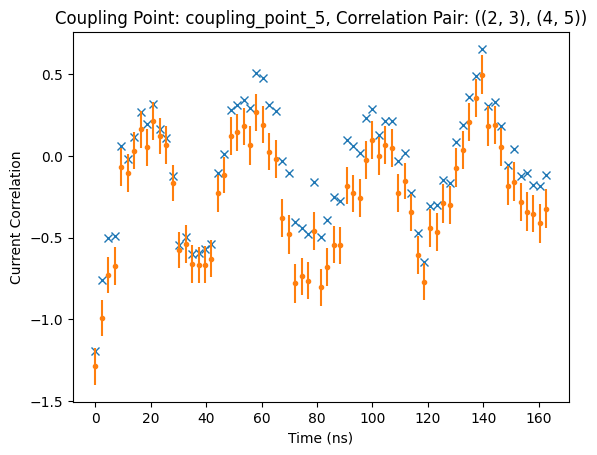

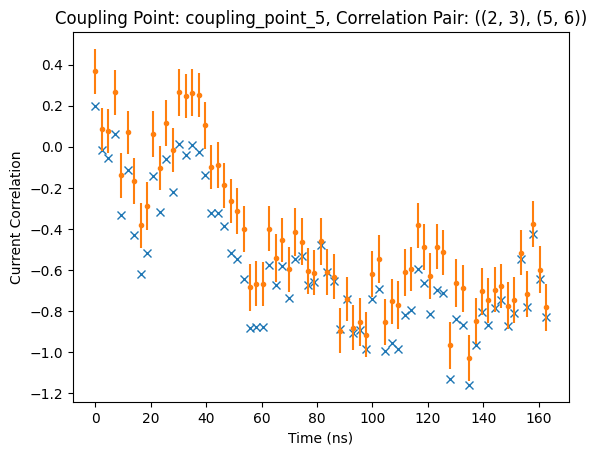

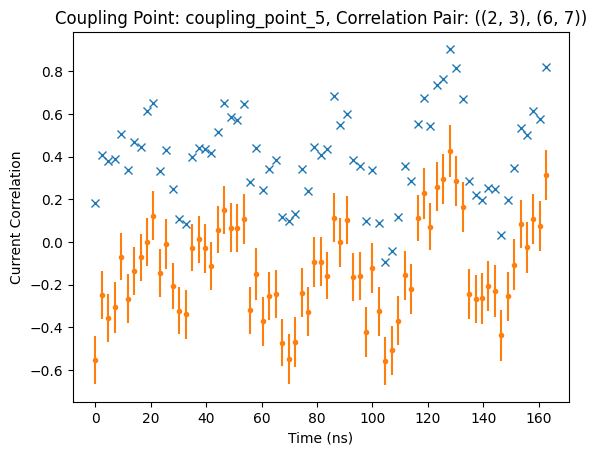

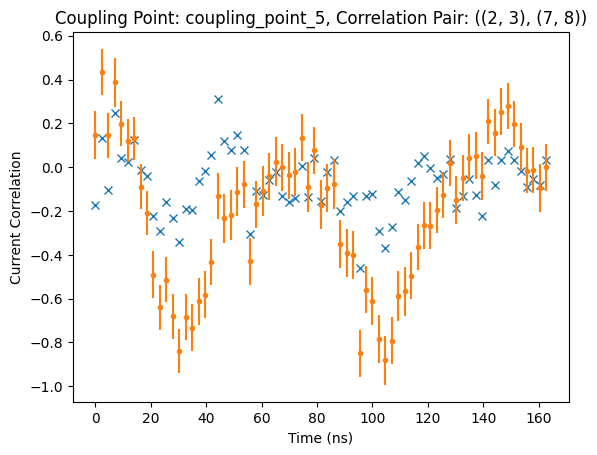

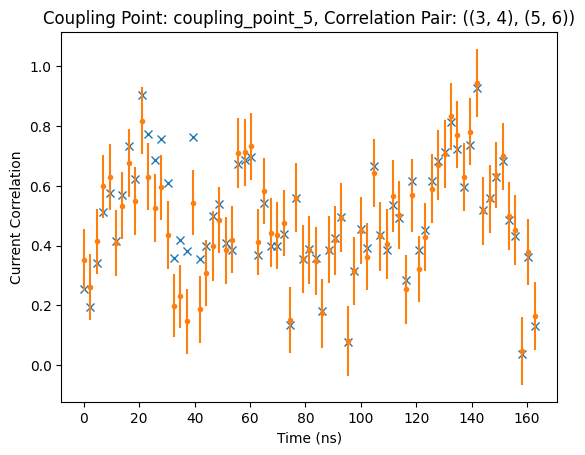

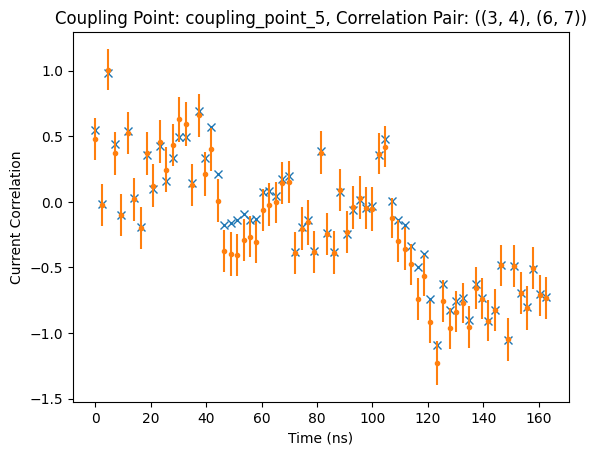

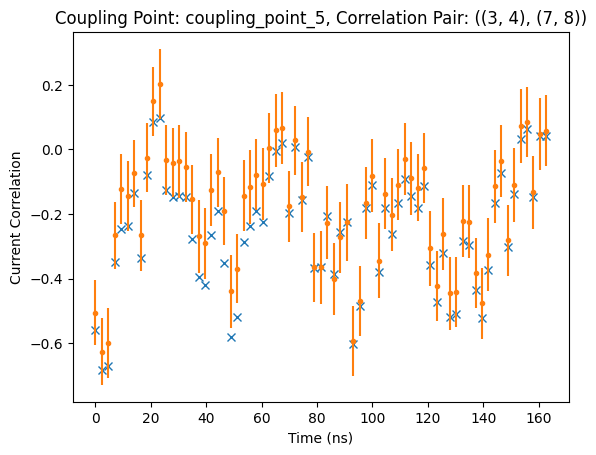

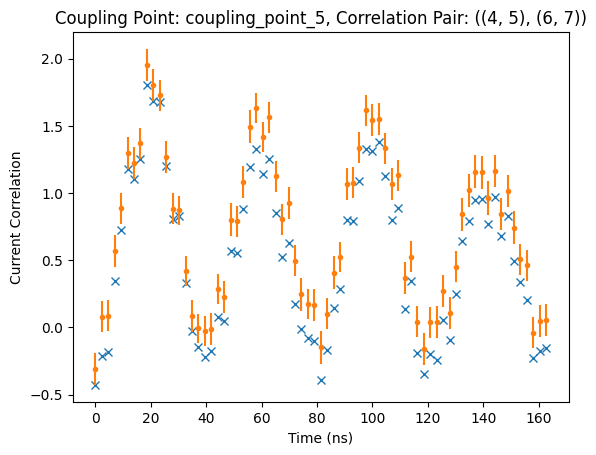

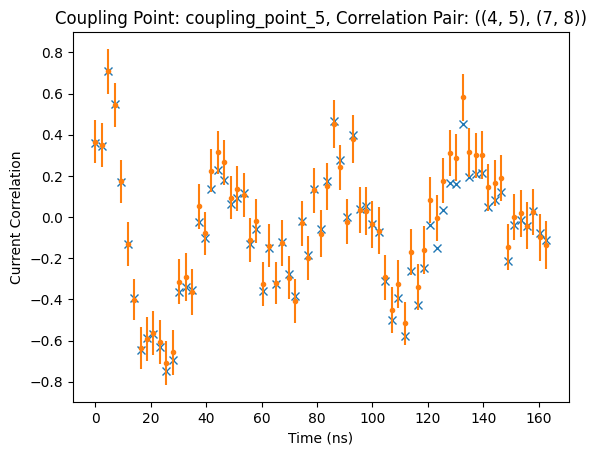

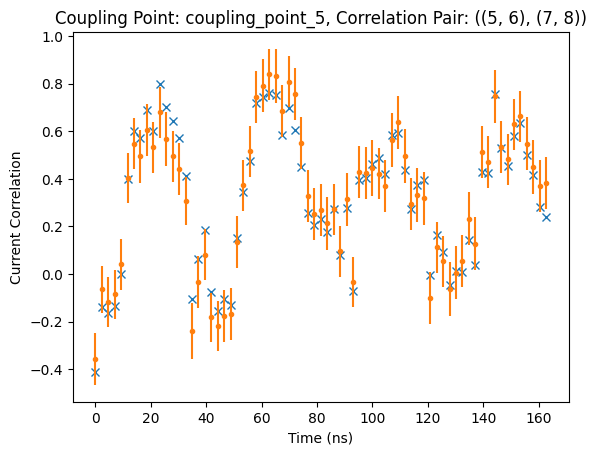

In [20]:
for coupling_point in coupling_points:

    if not coupling_point in ['coupling_point_5']:
        continue

    eigenstate = 'highest_postselection'

    for correlation_pair in correlation_pairs:
        if 'readout_error_means' not in reloaded_correlation_data['data'][coupling_point][eigenstate][str(correlation_pair)]:
            # print(f'correlation pair {correlation_pair} not found for coupling point {coupling_point} in bootstrap data')
            continue

        times = reloaded_correlation_data['data'][coupling_point][eigenstate][str(correlation_pair)]['times']
        current_correlation = reloaded_correlation_data['data'][coupling_point][eigenstate][str(correlation_pair)]['current_correlation']
        readout_error_means = reloaded_correlation_data['data'][coupling_point][eigenstate][str(correlation_pair)]['readout_error_means']
        readout_error_stds = reloaded_correlation_data['data'][coupling_point][eigenstate][str(correlation_pair)]['readout_error_stds']


        # clip for coupling point 5
        if coupling_point == 'coupling_point_5':
            readout_error_stds = np.clip(readout_error_stds, 0, 5)

        # if np.max(readout_error_stds) > 1:
        #     print(f'yes for {coupling_point} correlation pair {correlation_pair}')
        #     print(np.max(readout_error_stds))
        #     continue
        # else:
        #     continue

        plt.plot(times, current_correlation, linestyle='', marker='x', label='current correlation')
        # plt.plot(times, readout_error_means, linestyle='', marker='o', label='readout error mean')

        

        plt.errorbar(times, readout_error_means, yerr=readout_error_stds, fmt='o', markersize=3, label='correlation with error bars')
    
        plt.xlabel('Time (ns)')
        plt.ylabel('Current Correlation')
        plt.title(f'Coupling Point: {coupling_point}, Correlation Pair: {correlation_pair}')
        plt.show()

                                                                                

In [ ]:
# ### copy all post selected and corrected error bars to just post selection

# for i in range(len(coupling_points)):
#     coupling_point = coupling_points[i]

#     for k in range(len(correlation_pairs)):
#         correlation_pair = correlation_pairs[k]

#         if not str(correlation_pair) in reloaded_correlation_data['data'][coupling_point]['highest']:
#             continue

#         data_dictionary = reloaded_correlation_data['data'][coupling_point]['highest'][str(correlation_pair)]


#         keys = ('data',coupling_point, 'highest_postselection', str(correlation_pair))
#         update_data_file(correlation_data_filename, data_dictionary, keys, backup_dir=backup_dir, save_backup=True)